# Making a Neural Network from scratch (Optional)
We will try to make a neural network from scratch. This is an optional assignment. If you are even a little bit familiar with machine learning, know what neurons, weights, biases, feed-forward network, back propagration, gradient descent, activation functions are, then you can start right away. If not, don't worry. You can take a look at this medium article: https://medium.com/@waadlingaadil/learn-to-build-a-neural-network-from-scratch-yes-really-cac4ca457efc and try to learn what all these terms/topics are. Just knowing what they are won't help. I would recommend you to do the math along with the reading (because math is awesome!). Also avoid using for loops in this whole assignment. Now let's start!!

First, import the most important library required for machine learning (Tensorflow? Pytorch? No. We are not going to use premade models, so these libraries are not required). Guess the short form for the library too :)

In [2]:
## Import the library
import numpy as np

Now the neural network is for some dataset, right? We will use the MNIST dataset. It consists of 60k training images and 10k test images of size 28 $\times$ 28 with some digit written on each image. Our goal is to make a neural network which can identify the digit written on the image. Loading the dataset is done for you in the next block. Do not change the this block

In [ ]:
### DO NOT MODIFY THIS BLOCK
### This block has the class for loading the mnist dataset

import struct
from array import array
from os.path import join
import matplotlib.pyplot as plt
import random

class MnistDataloader(object):
    def __init__(self, training_images_filepath,training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath
    
    def read_images_labels(self, images_filepath, labels_filepath):        
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())        
        
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())        
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img            
        
        return images, labels
            
    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train),(x_test, y_test)
    
def show_images(images, title_texts):
    cols = 3
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(20,20))
    index = 1    
    for x in zip(images, title_texts):        
        image = x[0]        
        title_text = x[1]
        plt.subplot(rows, cols, index)        
        plt.imshow(image, cmap=plt.cm.gray)
        if (title_text != ''):
            plt.title(title_text, fontsize = 15);        
        index += 1

training_images_filepath = "mnist_dataset/train-images.idx3-ubyte"
training_labels_filepath = "mnist_dataset/train-labels.idx1-ubyte"
test_images_filepath = "mnist_dataset/t10k-images.idx3-ubyte"
test_labels_filepath = "mnist_dataset/t10k-labels.idx1-ubyte"

In [8]:
mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()

x_train and x_test have the images in array form, and y_train and y_test have the labels of the images. You can try printing the values in these variables to see in which format they are.

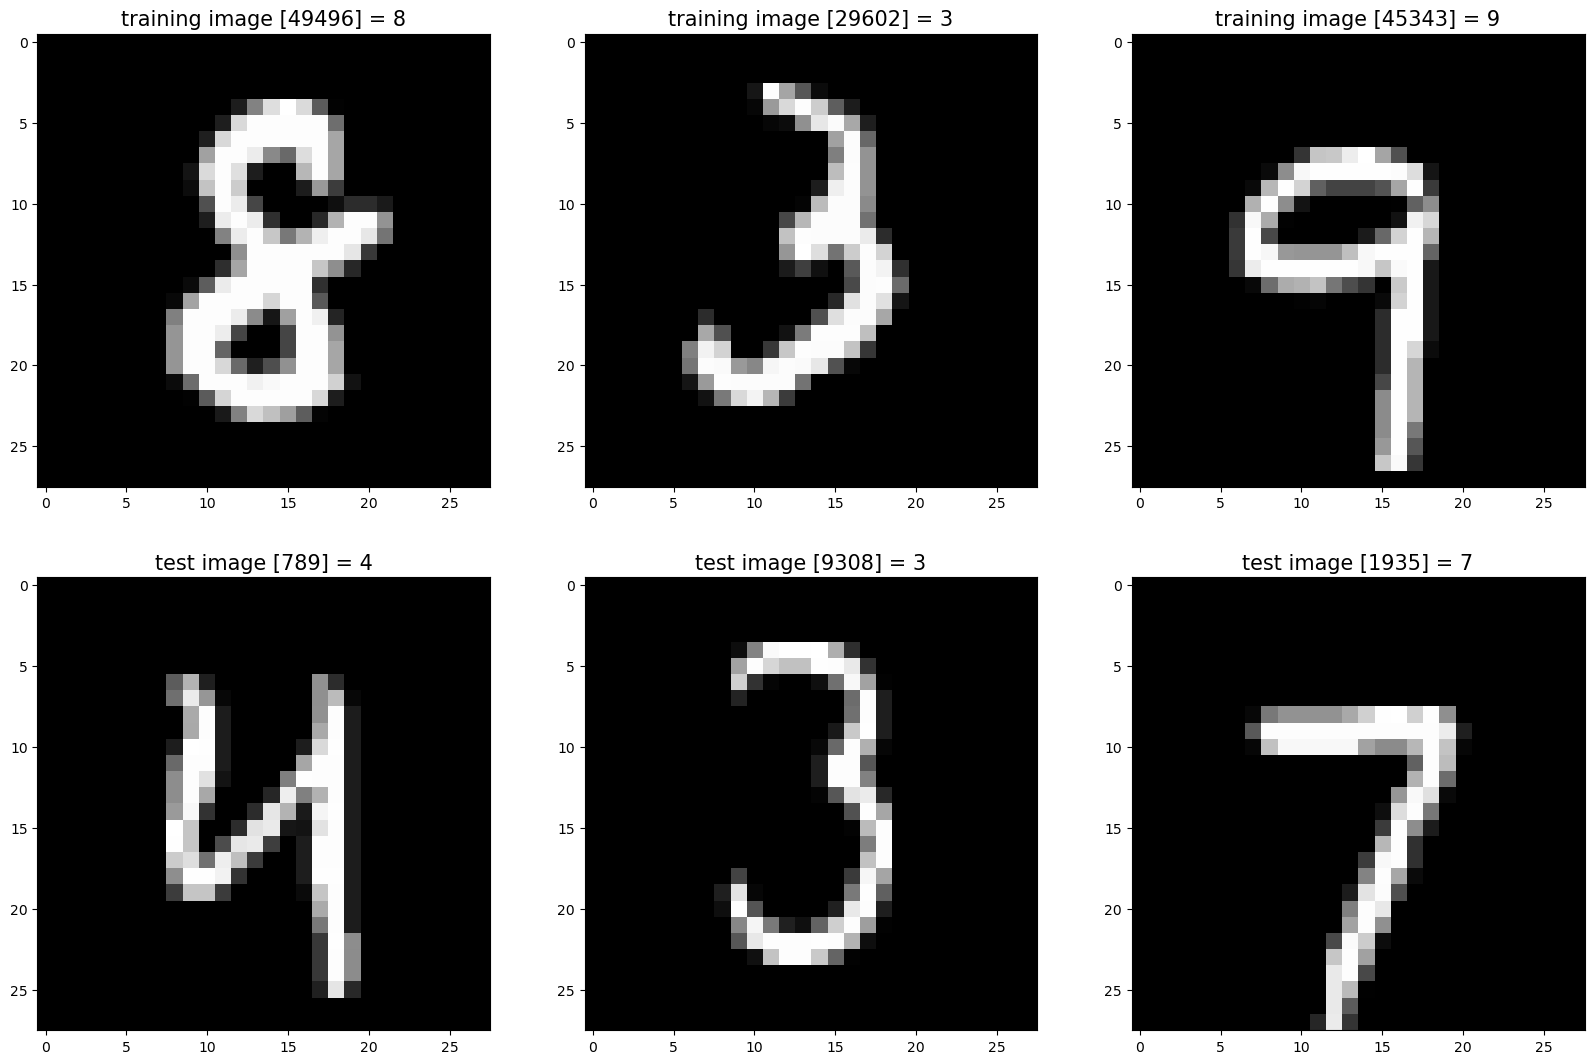

In [ ]:
images_2_show = []
titles_2_show = []
# 3 random training images
for i in range(0, 3):
    r = random.randint(1, 60000)
    images_2_show.append(x_train[r])
    titles_2_show.append('training image [' + str(r) + '] = ' + str(y_train[r]))    

# 3 random test images
for i in range(0, 3):
    r = random.randint(1, 10000)
    images_2_show.append(x_test[r])        
    titles_2_show.append('test image [' + str(r) + '] = ' + str(y_test[r]))    

show_images(images_2_show, titles_2_show)

## Data Preprocessing
Data preprocessing is a very important step in data analysis. It includes cleaning, integration, transformation, reduction, discretization and normalization. Outlier analysis is also an important step in preprocessing. Here, the data is clean (our work has been reduced). We will only scale the data. If you try printing the images, you will find out that the values in the array lies between 0 to 256. Scale this down to 0 to 1. Also convert the images x_train, x_test from list to numpy array

In [12]:
def scale(x_train, x_test):
	x_train = np.array(x_train)
	x_test = np.array(x_test)
	x_train = x_train/255
	x_test = x_test/255
	return x_train, x_test

x_train, x_test = scale(x_train, x_test)

One hot encoding is a method of representing the labels. You can read about it here: https://www.geeksforgeeks.org/ml-one-hot-encoding/ . We will convert y_train and y_test to numpy arrays and then one-hot encode them

#### Hint:
<details> You can use the function np.eye() for one-hot encoding </details>

In [ ]:
def one_hot(y_train, y_test):
	y_train = np.array(y_train)
	y_test = np.array(y_test)
	y_train = np.eye(10)[y_train]
	y_test = np.eye(10)[y_test]
	return y_train, y_test

y_train, y_test = one_hot(y_train, y_test)

## Building the neural network

We will make a neural network with 4 layers of neurons (1 input layer, 2 hidden layers, 1 output layer). The size of the layers (number of neurons in them) would be (784, 16, 16, __). Guess the final layers size and make a tuple n with these values.
Initialize the weights to some random values

In [5]:
n = (784, 16, 16, 10) # Replace __ with the correct values
W1 = np.random.randn(n[0], n[1])
W2 = np.random.randn(n[1], n[2])
W3 = np.random.randn(n[2], n[3])
b1 = np.random.randn(n[1])
b2 = np.random.randn(n[2])
b3 = np.random.randn(n[3])

print(W1.shape, b1.shape)
print(W2.shape, b2.shape)
print(W3.shape, b3.shape)


(784, 16) (16,)
(16, 16) (16,)
(16, 10) (10,)


In [ ]:
class NN:
	def __init__(self):
		pass

	def feed_forward(self):
		pass

	def loss(self):
		pass
	
	def back_propagation(self):
		pass

	def train(self):
		pass

	def predict(self):
		pass

	def accuracy(self):
		pass
